# Physics 113 Final Project: Stellarators

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json

## Part 0: Load Plasma Shape

In [2]:
with open("constellaration_row0.json", "r") as f:
    row = json.load(f)

In [3]:
# cylindrical coordinates
r_cos = np.array(row["boundary.r_cos"])   # Fourier coefficients for the cosine terms, shape: (n_periodicity+1, 2*n_periodicity+1) or flat
z_sin = np.array(row["boundary.z_sin"])   # Fourier coefficients for the sine terms, same shape
Nfp   = row["boundary.n_field_periods"]   # number of field periods
nmax  = row["boundary.n_periodicity"]     # max poloidal/toroidal mode number, max number of terms in the Fourier, controls model simplicity


m_max: 5   nmax_actual: 4
R_00: 0.9994871156625027
R range: 0.6506282425032026 1.2890100022946422
Z range: -0.3147245563323342 0.31472455633233426


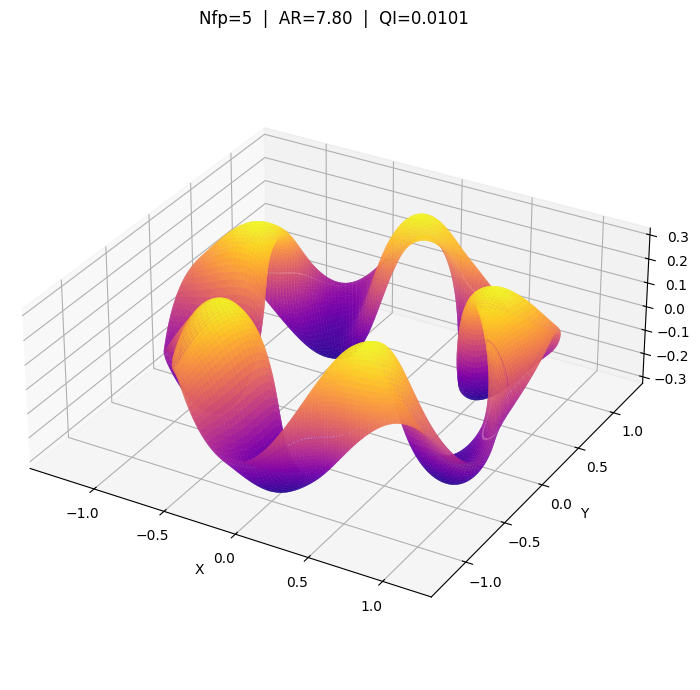

In [4]:
r_cos = np.array(row["boundary.r_cos"])
z_sin = np.array(row["boundary.z_sin"])
Nfp   = row["boundary.n_field_periods"]

# Derive mode numbers directly from array shape — don't trust n_periodicity
m_max   = r_cos.shape[0]           # 5  → m = 0, 1, 2, 3, 4
n_cols  = r_cos.shape[1]           # 9  → n = -4, -3, ..., 0, ..., 4
nmax_actual = (n_cols - 1) // 2    # 4

print("m_max:", m_max, "  nmax_actual:", nmax_actual)
print("R_00:", r_cos[0, nmax_actual])   # should now be ~0.7–1.0

# Reconstruct
N_theta, N_phi = 128, 128
theta = np.linspace(0, 2*np.pi, N_theta, endpoint=False)
phi   = np.linspace(0, 2*np.pi / Nfp, N_phi, endpoint=False)
TH, PH = np.meshgrid(theta, phi)

R = np.zeros_like(TH)
Z = np.zeros_like(TH)

for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual          # maps ni=0→n=-4, ni=4→n=0, ni=8→n=+4
        angle = m * TH - n * Nfp * PH
        R += r_cos[m, ni] * np.cos(angle)
        Z += z_sin[m, ni] * np.sin(angle)

print("R range:", R.min(), R.max())   # expect ~0.5 to 1.5
print("Z range:", Z.min(), Z.max())   # expect ~-0.3 to 0.3

# To one full torus (repeat Nfp times around phi)
phi_full  = np.linspace(0, 2*np.pi, N_phi * Nfp, endpoint=False)
TH2, PH2  = np.meshgrid(theta, phi_full)

R2 = np.zeros_like(TH2)
Z2 = np.zeros_like(TH2)
for m in range(m_max):
    for ni in range(n_cols):
        n = ni - nmax_actual
        angle = m * TH2 - n * Nfp * PH2
        R2 += r_cos[m, ni] * np.cos(angle)
        Z2 += z_sin[m, ni] * np.sin(angle)

X2 = R2 * np.cos(PH2)
Y2 = R2 * np.sin(PH2)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X2, Y2, Z2, cmap='plasma', alpha=0.9,
                rstride=2, cstride=2)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 0.4])    # flatten Z so the torus doesn't look squashed
ax.set_title(f"Nfp={Nfp}  |  AR={row['metrics.aspect_ratio']:.2f}  |  QI={row['metrics.qi']:.4f}")
plt.tight_layout()
plt.show()

## Part 1: Coil Design

In [ ]:
# ----------------------------------------------------------------------------------------------------------------------------------------------------
# Compute plasma boundary shape at 4 evenly spaced out toroidal slices
# ----------------------------------------------------------------------------------------------------------------------------------------------------

phi_slice_values = 0, (np.pi / 2), np.pi, (3 * np.pi / 2)

theta_vals = np.linspace(0, 2 * np.pi, 300, enpoint = True) # theta around cross-section

# Store the shapes of the boundaries 
plasma_boundaries = []

for phi_val in phi_slice_values: 
    # R and Z give the 2D boundary shape 
    R_boundary = np.zeros_like(theta_vals) 
    Z_boundary = np.zeros_like(theta_vals)

    # Use Fourier coefficients to reconstruct the boundary curve at a fixed phi value
    for m in range(m_max):
        for coefficient_index in range(n_cols):
            
            n = coefficient_index - nmax_actual
            
            fourier_angle = m * theta_vals - n * Nfp * phi_val

            R_boundary += r_cos[m, coefficient_index] * np.cos(fourier_angle)
            Z_boundary += z_sin[m, coefficient_index] * np.sin(fourier_angle)

    # Convert boundary from cylindrical coordinates to cartesian coordiantes
    X_boundary = R_boundary * np.cos(phi_val)
    Y_boundary = R_boundary * np.sin(phi_val)

    # Store each boundary shape as a dictionary
    boundary = {
        "phi_val": phi_val,
        "theta_vals": theta_vals,
        # 2D cross-section coordinates
        "R": R_boundary,
        "Z": Z_boundary,
        # 3D coordiantes (cartesian)
        "X": X_boundary,
        "Y": Y_boundary,
        "Z": Z_boundary
    }

    plasma_boundaries.append(boundary)